## <center>**Asignacion 2:** EDA</center>

### **1. Descripción del dataset:**

Primero, importaremos los datos.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette("Set2")
%matplotlib inline

data = pd.read_csv("./bankloan.csv")

Ahora, se mostrata: Numero de filas, columnas y tipos de datos

In [3]:
print(f"Número de filas: {data.shape[0]}", end="\n\n")
print(f"Número de columnas: {data.shape[1]}", end="\n\n")
data.info()

Número de filas: 5000

Número de columnas: 14

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP.Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal.Loan       5000 non-null   int64  
 10  Securities.Account  5000 non-null   int64  
 11  CD.Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


Se puede ver que todos los tipos de datos son numéricos, aunque hay variables categóricas o booleanas, como por ejemplo Family y Online.  


### **2. Estadísticas descriptivas:**

Ahora, se obtendran descriptores estadisticos para las columnas numericas, cabe resaltar que para esta parte no se tomaron en cuenta variables numericas que representaban valores booleanos (0 o 1)

In [ ]:
numeric_columns =  ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

desc_stats = pd.DataFrame({
    'Variable': numeric_columns,
    'Media': [data[col].mean() for col in numeric_columns],
    'Mediana': [data[col].median() for col in numeric_columns],
    'Desv. Estándar': [data[col].std() for col in numeric_columns],
    'Mínimo': [data[col].min() for col in numeric_columns],
    'Máximo': [data[col].max() for col in numeric_columns]
})

desc_stats = desc_stats.round(2)
print("\n")
print(desc_stats.to_string(index=False))




  Variable  Media  Mediana  Desv. Estándar  Mínimo  Máximo
       Age  45.34     45.0           11.46    23.0    67.0
Experience  20.10     20.0           11.47    -3.0    43.0
    Income  73.77     64.0           46.03     8.0   224.0
     CCAvg   1.94      1.5            1.75     0.0    10.0
  Mortgage  56.50      0.0          101.71     0.0   635.0


A simple vista se noto que el minimo valor para los anios de experiencia era un valor negativo, asi que para complementar esta parte, se mostrara la cantidad de usuarios con experiencia negativa

In [5]:
negative_exp = data[data['Experience'] < 0]
print(f"Cantidad de registros con experiencia negativa: {len(negative_exp)}")
print(f"Porcentaje del total: {(len(negative_exp)/len(data)*100):.2f}%")

Cantidad de registros con experiencia negativa: 52
Porcentaje del total: 1.04%



### **3. Valores faltantes:**

Ahora, se evaluara la cantidad de valores nulos por columna.

In [6]:
missing_values = data.isnull().sum()
print("Cantidad de valores nulos por columna:")
display(missing_values)



Cantidad de valores nulos por columna:


ID                    0
Age                   0
Experience            0
Income                0
ZIP.Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal.Loan         0
Securities.Account    0
CD.Account            0
Online                0
CreditCard            0
dtype: int64

### **4. Histogramas:**

Para este paso se haran histogramas sobre las variables numericas

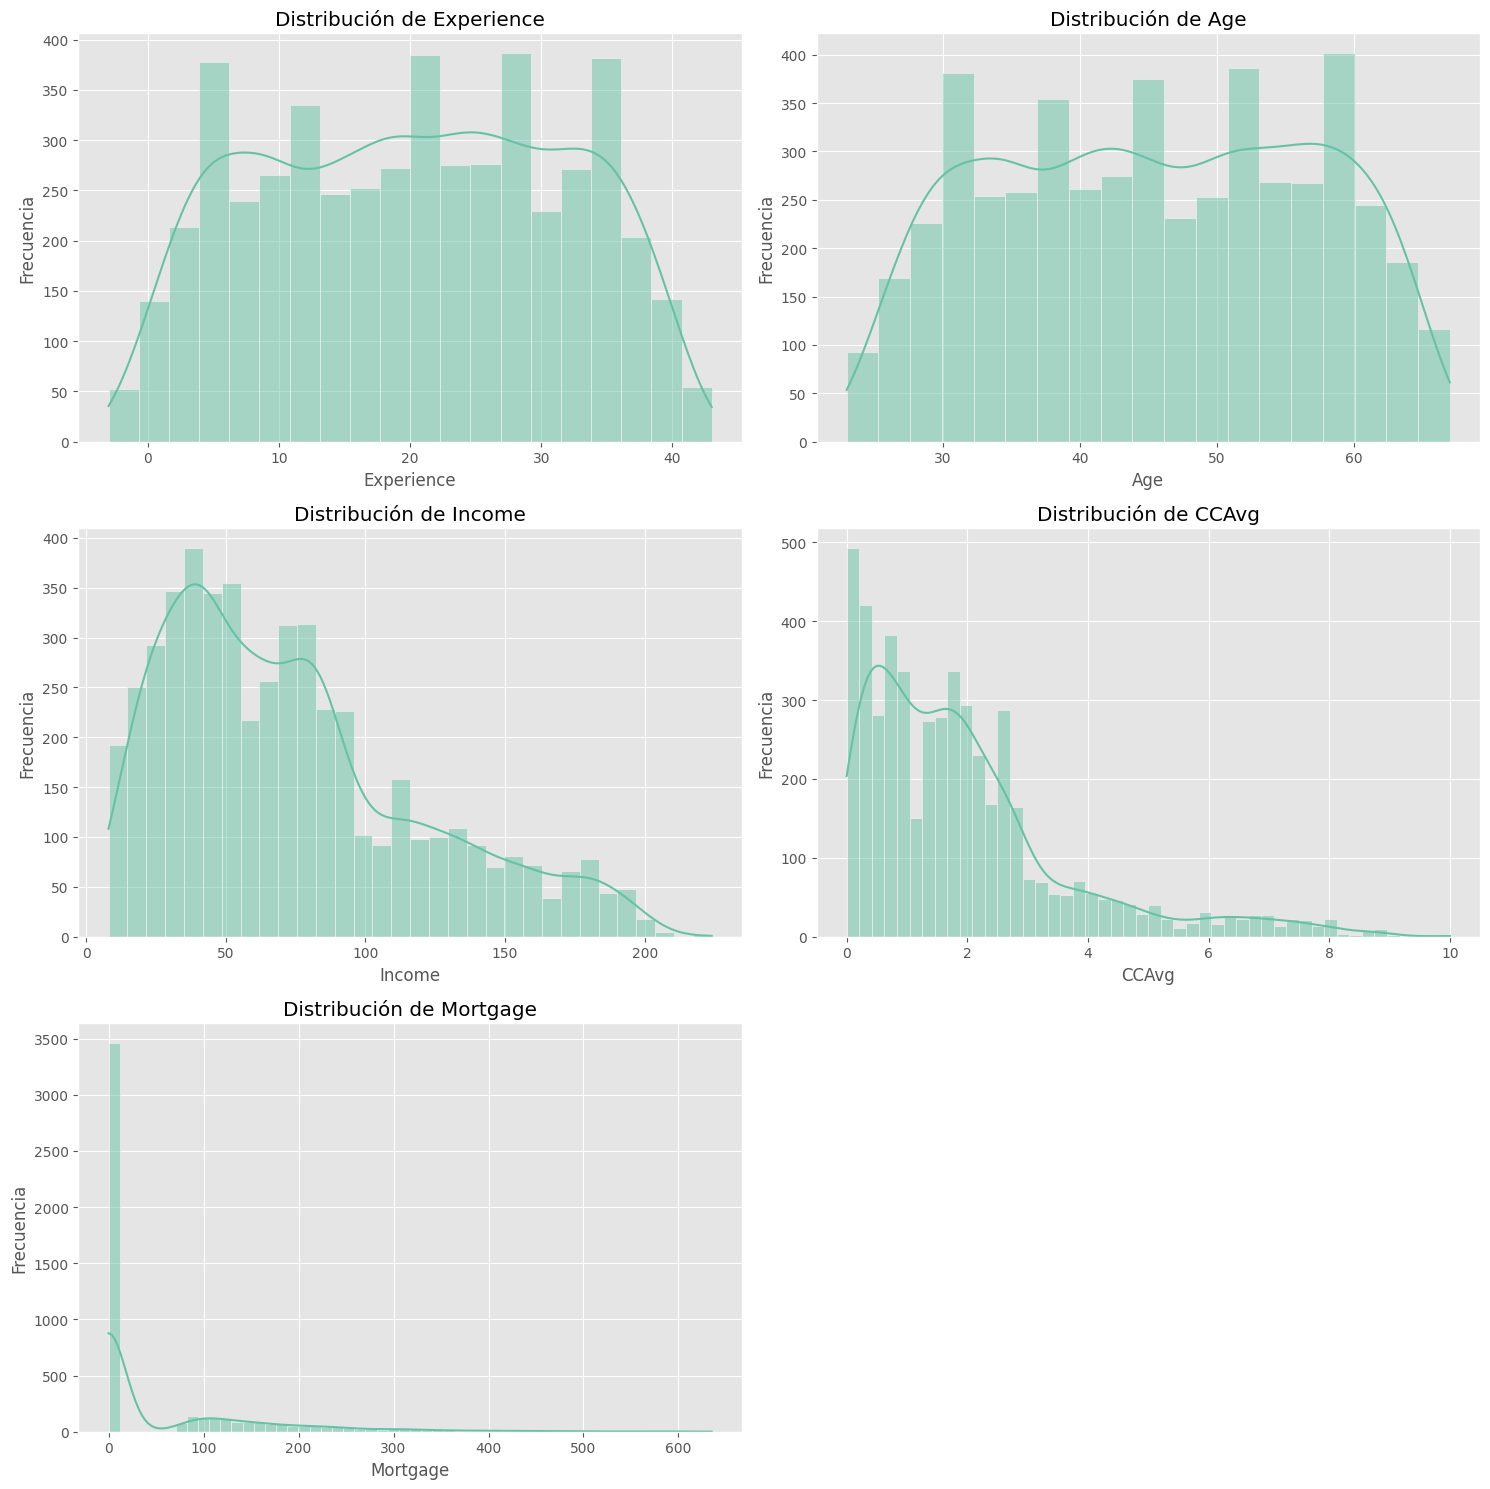

In [ ]:
# variables para los histogramas
variables_numericas = ['Experience', 'Age', 'Income', 'CCAvg', 'Mortgage']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten() 

# histograma para cada variable
for i, col in enumerate(variables_numericas):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

if len(variables_numericas) % 2 != 0:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

Los histogramas muestran que la mayoría de las variables presentan distribuciones normales para estos tipos de datos, por ejemplo Age tiene distribución uniforme entre 23 y 67 años, mientras que Income y CCAvg muestran sesgos hacia la derecha con outliers en valores altos. Mortgage presenta una distribución particular con un exceso de ceros (clientes sin hipoteca). Ademas, se confirma la existencia de valores negativos para Experiencie.

Se haran los mismos histogramas agregando la aprobación o no del prestamo

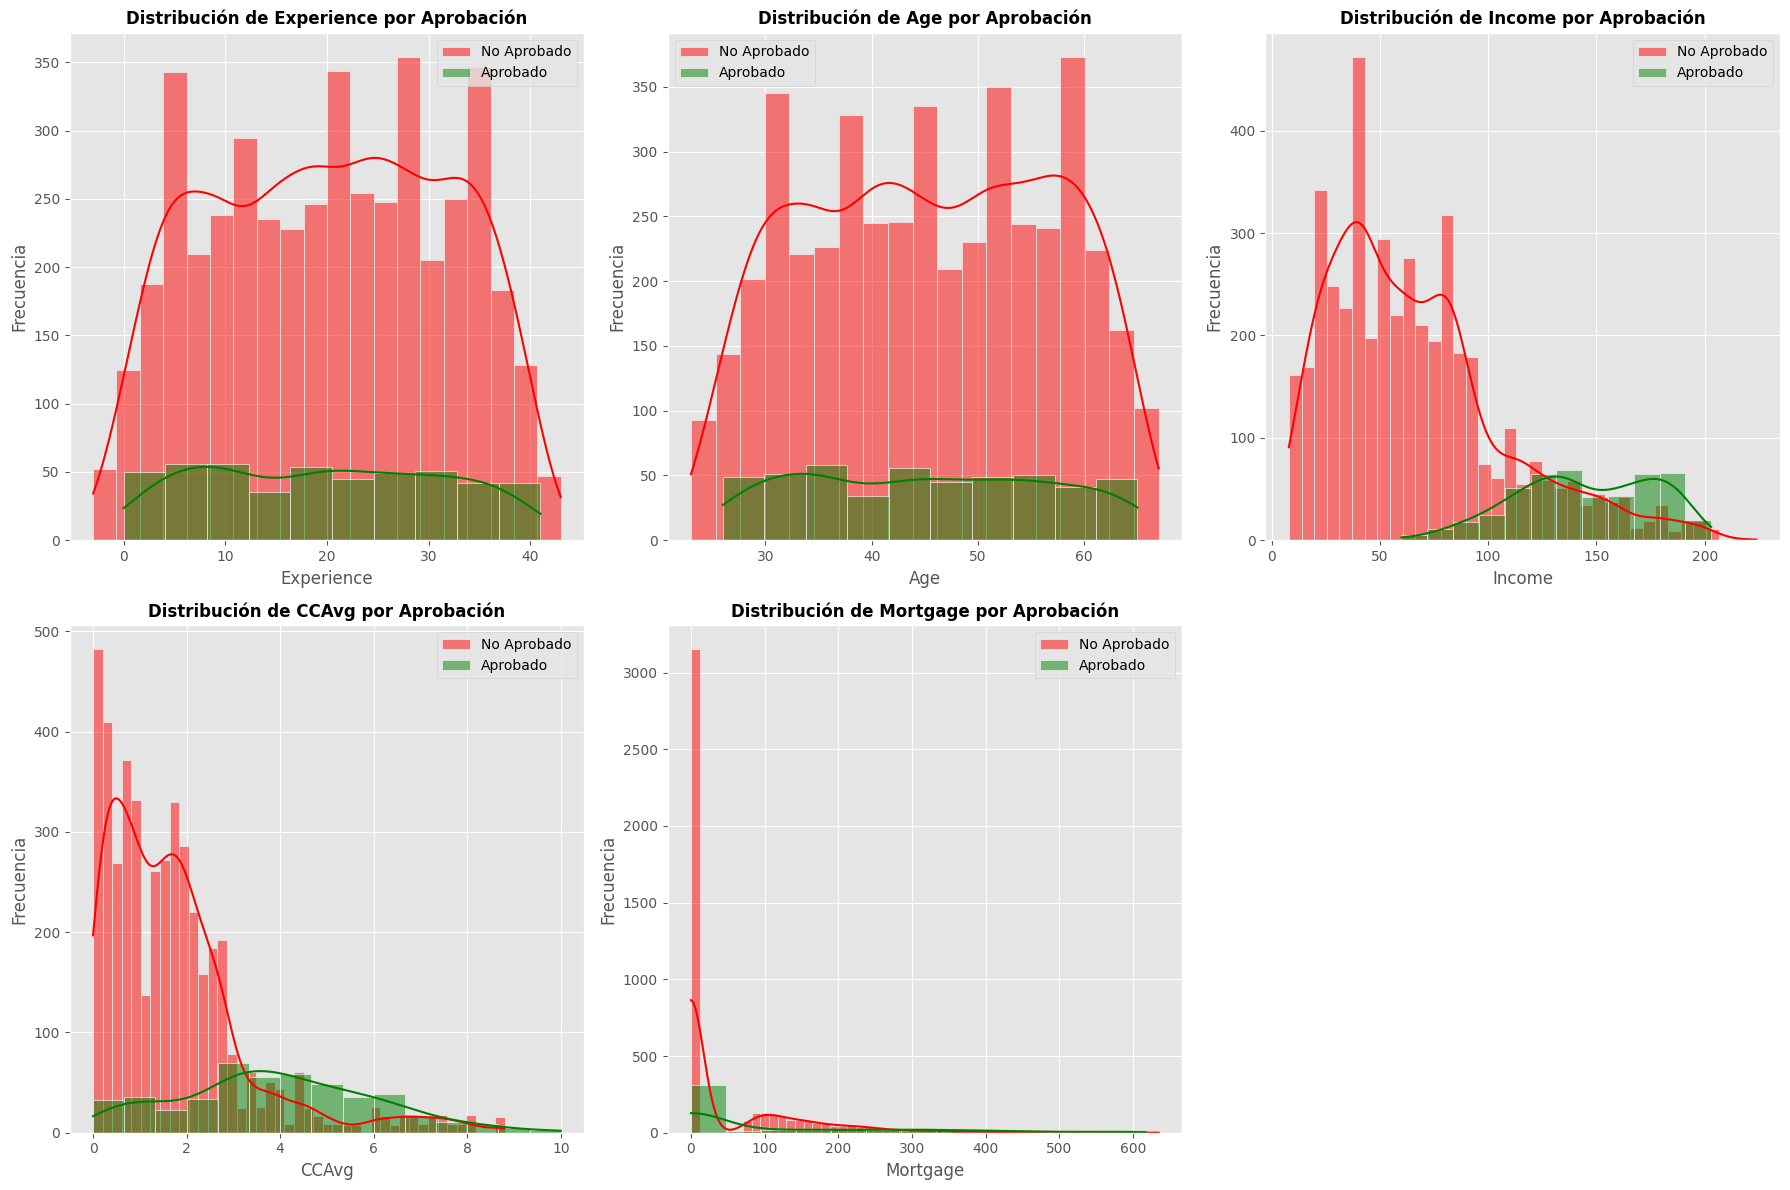

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    # Histograma para no aprobados
    sns.histplot(data[data['Personal.Loan'] == 0][col], 
                 color='red', alpha=0.5, label='No Aprobado', 
                 kde=True, ax=axes[i])
    
    # Histograma para aprobados
    sns.histplot(data[data['Personal.Loan'] == 1][col], 
                 color='green', alpha=0.5, label='Aprobado', 
                 kde=True, ax=axes[i])
    
    axes[i].set_title(f'Distribución de {col} por Aprobación', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

if len(variables_numericas) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

Viendo esto, tenemos que Income es el factor más determinante a la ahora de la aprobación, luego le podría seguir el gasto en tarjeta de crédito.


### **5. Box plots: Genere box plots:**

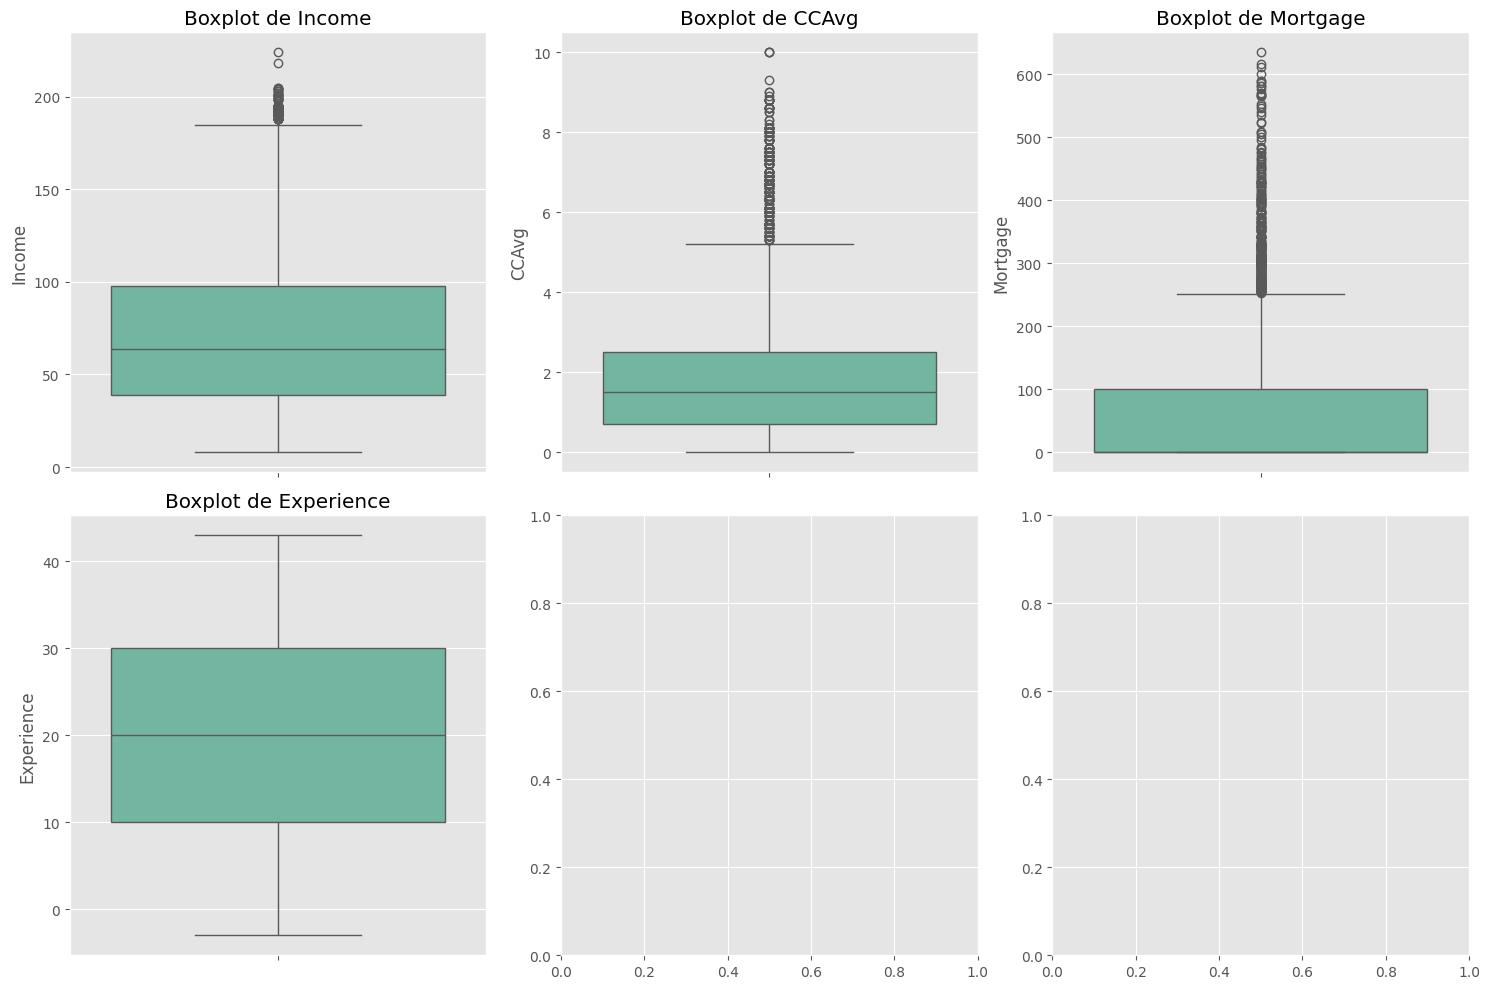

In [9]:
# Box plots individuales
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
variables = ['Income', 'CCAvg', 'Mortgage', 'Experience']

for i, var in enumerate(variables):
    row, col = i//3, i%3
    sns.boxplot(y=data[var], ax=axes[row, col])
    axes[row, col].set_title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

Los boxplots revelan una presencia de posibles valores anómalos en múltiples variables, tipo en Income se observan outliers superiores muy por encima de su mediana, cosa similar ocurre con CCAvg, y en Mortgage los outliers se extienden hasta 600K, contrastando con una mediana de 0 que indica que la mayoría de clientes no tiene hipoteca. Pero aun asi, estos casos atípicos, puedesn representar perfiles de clientes de alto valor financiero.

Se va a complementar tomando en cuenta la aprobación.

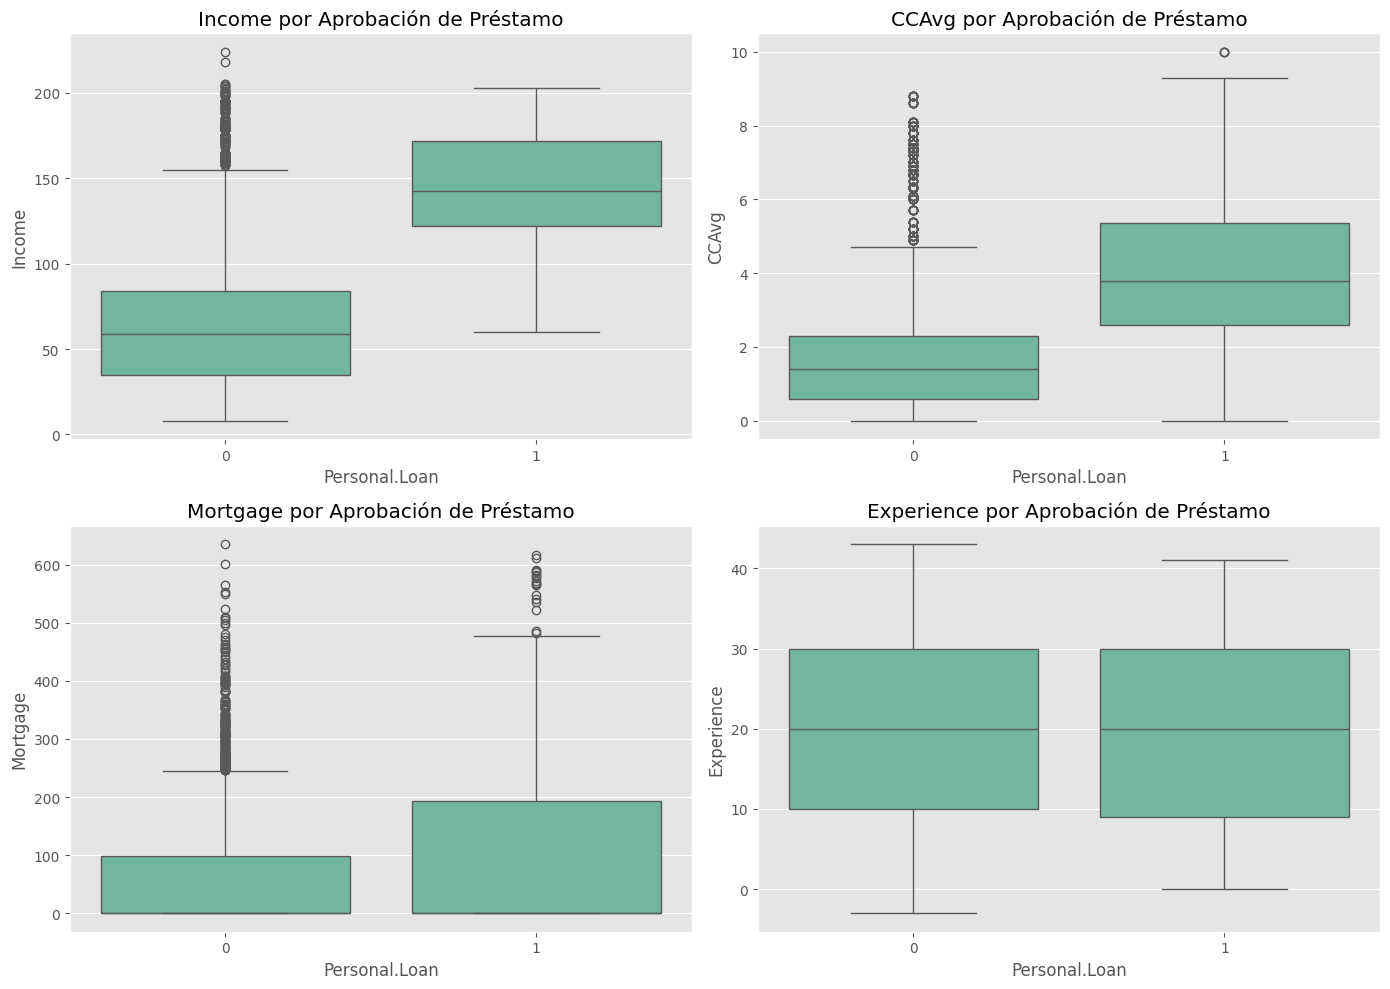

In [ ]:
# aprobados vs no aprobados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
variables = ['Income', 'CCAvg', 'Mortgage', 'Experience']

for i, var in enumerate(variables):
    row, col = i//2, i%2
    sns.boxplot(x='Personal.Loan', y=var, data=data, ax=axes[row, col])
    axes[row, col].set_title(f'{var} por Aprobación de Préstamo')
plt.tight_layout()
plt.show()

Aunque el ingreso aparece como el principal factor relacionado con la aprobación de préstamos, los boxplots revelan que existen casos de personas con ingresos altos que no fueron aprobadas, lo que indica que el banco evalúa un perfil más integral del solicitante, esto se observa en otras variables como el gasto en tarjeta (CCAvg) o la tenencia de hipoteca (Mortgage) donde valores elevados no garantizan automáticamente la aprobación.

### **6. Análisis de correlación:**

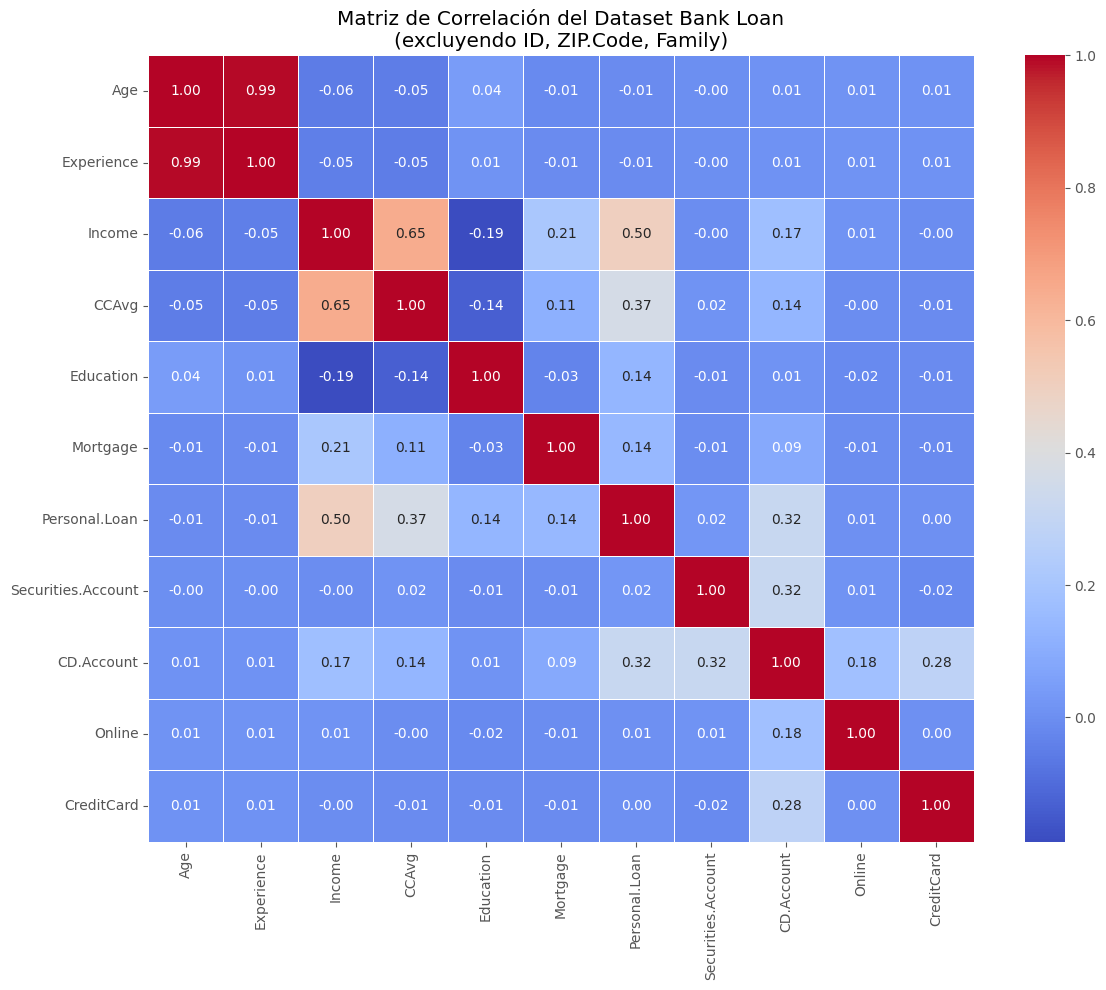

In [ ]:
# excluir variables no relevantes
variables_a_excluir = ['ID', 'ZIP.Code', 'Family'] 
variables_para_correlacion = [col for col in data.columns if col not in variables_a_excluir]

correlation_matrix = data[variables_para_correlacion].corr(numeric_only=True)

plt.figure(figsize=(12, 10))

# heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación del Dataset Bank Loan\n(excluyendo ID, ZIP.Code, Family)')
plt.tight_layout()
plt.show()

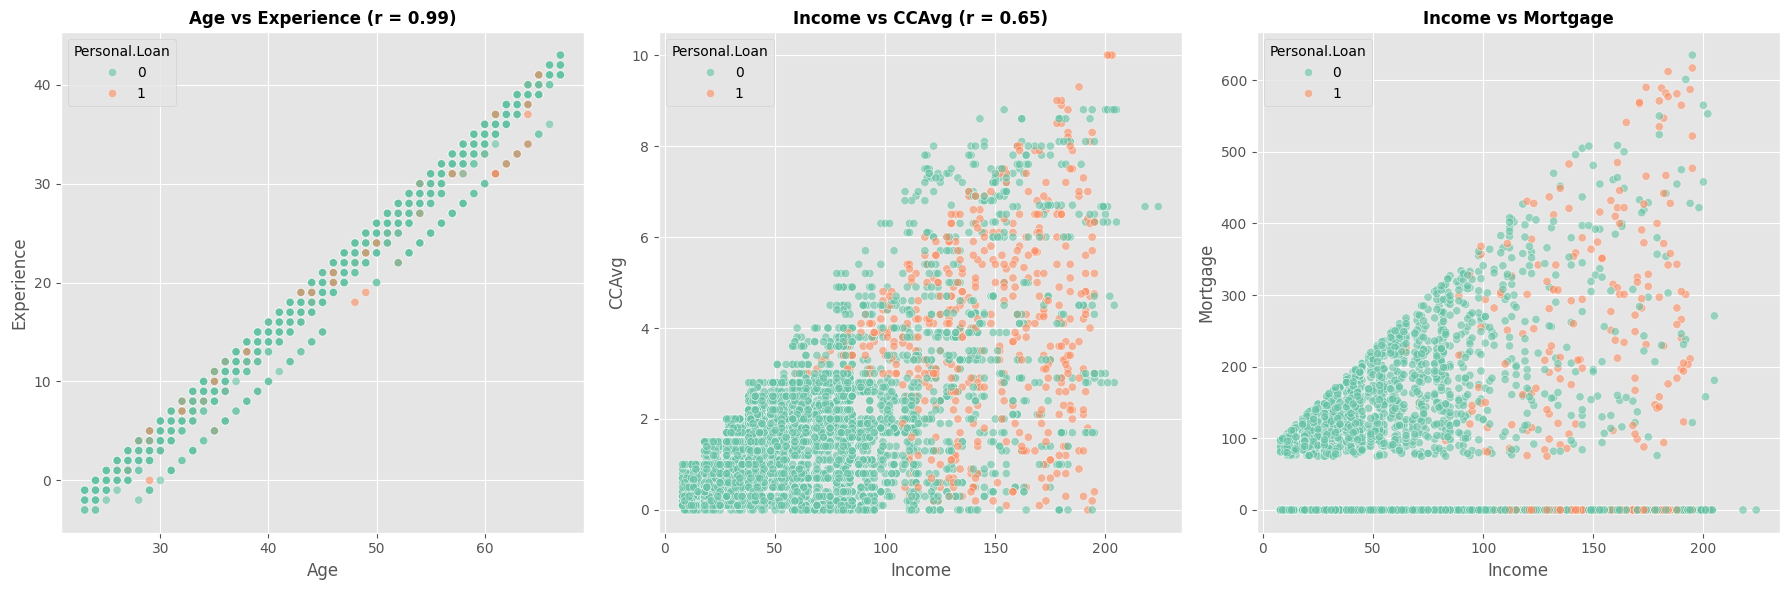

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

# Age vs Experience
sns.scatterplot(data=data, x='Age', y='Experience', hue='Personal.Loan', 
                alpha=0.6, ax=axes[0])
axes[0].set_title('Age vs Experience (r = 0.99)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Experience')

# Income vs CCAvg 
sns.scatterplot(data=data, x='Income', y='CCAvg', hue='Personal.Loan', 
                alpha=0.6, ax=axes[1])
axes[1].set_title('Income vs CCAvg (r = 0.65)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('CCAvg')

# Income vs Mortgage
if 'Mortgage' in data.columns:
    sns.scatterplot(data=data, x='Income', y='Mortgage', hue='Personal.Loan', 
                    alpha=0.6, ax=axes[2])
    axes[2].set_title('Income vs Mortgage', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Income')
    axes[2].set_ylabel('Mortgage')

plt.tight_layout()
plt.show()

Con respecto a Age vs Experience podemos ver una relación lineal casi perfecta, como era de esperarse y no hay diferencias entre aprobados y no aprobados

En Income vs CCAvg hay una relación positiva clara, a mayor ingreso, mayor gasto en tarjeta y en donde los aprobados (puntos amarillos) se concentran un poco más en la zona superior derecha

Pero en Income vs Mortgage hay una dispersión un poco mas grande, por lo que tener hipoteca no es determinante, pero ingreso alto sí lo es

Ccomo conclusión, podemos tener que Income y CCAvg juntas definen el perfil del cliente aprobado en mayor medida.